# Das Diagramm schöner machen

Was benötigt ein brauchbares Diagramm?

* Gitternetzlinien
* Achsenbeschriftungen
* Eine Überschrift

Was in den Naturwissenschaften eher unüblich ist, sind richtige Koordinatenachsen,  
wie du sie immer in Mathematik zeichnest. Dafür können hier auch schon mal zwei   
verschiedene y-Achsen vokommen (linker und rechter Rand des Diagramms), wenn   
gleichzeitig verschiedene Daten gezeichnet werden sollen. 

Lass uns das Diagramm verfeinern. Beginnen wir mit folgendem Stand:

```python
x_werte = [0,1,2,3,4]
y_werte = [0,1,4,9,16]

plt.plot(x_werte, y_werte)
```

Ein Gitternetz wird als `grid` bezeichnet. Du kannst es ganz einfach erstellen, indem du **vor**  
den `plot`-Befehle schreibst: `plt.grid()`  
Es gibt da allerdings noch einen kleinen Schöheitsfehler, wenn es um Mathematik geht!

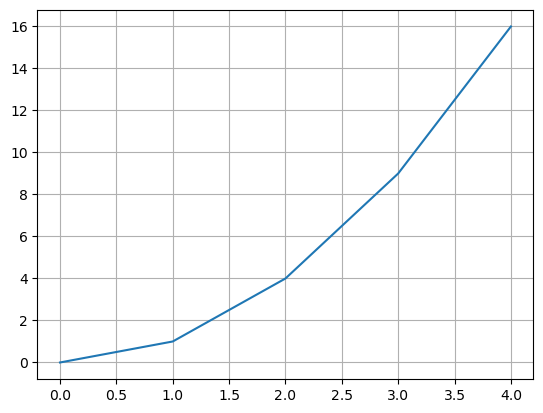

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

x_werte = [0,1,2,3,4]
y_werte = [0,1,4,9,16]

plt.grid()
plt.plot(x_werte, y_werte)

* Das Gitternetz ist nicht quadratisch.
* Die Beschriftung der Achsen ist nicht einheitlich, was die Abstände betrifft.
* Wir haben noch kein Koordinatenkreuz.
  
Das sind - wie gesagt - alles keine Problem in Physik, Chemie, Biologie ... nur in Mathe eben unüblich!  

Wie bekommen wir das in den Griff? Du könntest z.B. eine KI um Hilfe bitten!

> Ich erstelle aktuell den Graphen einer quadratischen Funktion mit PyPlot.  
> Das funktioniert im Prinip mit folgenden Einschränkungen:  
> * Das Gitternetz ist nicht quadratisch.
> * Die Beschriftung der Achsen ist nicht einheitlich, was die Abstände betrifft.
> * Wir haben noch kein Koordinatenkreuz.
> * Die Beschriftung soll an den Achsen stehen
> * Erweitere die Definitionsmenge auf den Bereich -4 bis 4

Erstelle den Code für den gesamten Plot.


## Was macht die KI?

Sie liefert dir Code, der *extrem* von unserem Ansatz abweicht.  

Ist das schlimm?  

Wenn du ihn lesen und anpassen kannst, dann nicht. Dafür musst du ihn aber *verstehen*.  
Ich zeige dir den Code, den ich von Chat-GPT bekommen habe. Wir gehen ihn Zeile für Zeile  
durch und du wirst viele bekannte Stellen entdecken!


```python
# Diese Imports kennst du, Pandas wird nicht verwendet
import numpy as np
import matplotlib.pyplot as plt

# Definieren der Funktion f(x) an Stelle von x_wert**2 ...
def f(x):
    return x**2 - 2*x - 3

# Definitionsmenge von -4 bis 4, Wertetabelle aufbauen.
# Hier kommt der *numpy*-Trick zum Einsatz!
x = np.linspace(-4, 4, 400)
y = f(x)

# DAS ist neu! Sieht seltsam aus. 
# *fig* ist der Zeichenbereich
# *ax* steht für den kompletten späteren Graphen.
fig, ax = plt.subplots()

# Statt direkt *plt.plot* zeichen wir zuerst in *ax*
# Das label könntest du auch löschen
ax.plot(x, y, label="f(x) = x² - 2x - 3")

# Quadratisches Gitternetz
# *aspect* bedeutet *Seitenverhältnis* des Gitters
# adjustable='box'   ... einfach merken :) weglassen geht oft auch
ax.set_aspect('equal', adjustable='box')

# Einheitliche Achsenbeschriftung
# Das ist wieder eine *numpy* - Stelle ...
ax.set_xticks(np.arange(-4, 5, 1))
ax.set_yticks(np.arange(-4, 11, 1))

# Gitternetz zeichnen
ax.grid(True)

# Koordinatenkreuz erzeugen
# Dafür werden der linke und untere Rahmen in den Ursprung geschoben
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')

# Oberen und rechten Rahmen ausblenden
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')

# Beschriftung an den Achsen unterhalb (=x) und linls (=y)
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

# Achsenbereich für die Zeichnung
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 10)

# Legende ... falls du sie willst
ax.legend()

# Anzeigen
plt.show()
```

Ja - auch das sind sehr viele Zeilen und merken wirst du sie dir nicht!   
Auf der anderen Seite ist es eine Schablone. Du musst nicht viel abändern,   
um jede beliebige andere Funktion zu zeichnen. Damit kannst du ohne lästige  
Assistenten schnell saubere Plots machen ...   
... aber natürlich ist das für eine Parabel absolut *überdimensioniert*,   
das kann GeoGebra mindestens genau so gut!

## WARUM sollte ich mir das dann antun?

Praktisches Beispiel. Ich habe im März einen neuen Akku für meine PV-Anlage angeschafft.   
Nun würde ich gerne darstellen, wie sich die Ladung und Entladung in dieser Zeit entwickelt hat.  
Diese Daten zeichne ich in Intervallen von 5 Minuten auf. Probieren wir eine Darstellung und vergleichen   
dann den Aufwand mit einer Tabellenkalkulation!

Die Daten findest du am linken Rand als `solar.csv`.